In [2]:
import jax
import jax.numpy as jnp
import optax
import jaxopt  # Install with: pip install jaxopt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from jax import grad, vmap, hessian, jit, random
import functools

# 1. Setup & Hyperparameters
key = random.PRNGKey(42)

STEPS = 30000
C = 1.0  # Wave speed
layers = [3, 60, 60, 1]  # Input: (x, y, t), Output: u
n_points_bulk = 10000
n_points_initial_time = 100
n_points_boundary = 100
xi = 0.0
xf = 1.0
yi = 0.0
yf = 1.0
ti = 0.0
tf = 1.0

# 2. Network Architecture (Input: x, y, t -> Output: u)
def init_params(layers, key):
    params = []
    keys = random.split(key, len(layers) - 1)
    for i, (d_in, d_out) in enumerate(zip(layers[:-1], layers[1:])):
        w = random.normal(keys[i], (d_in, d_out)) * jnp.sqrt(2 / (d_in + d_out))
        b = jnp.zeros(d_out)
        params.append({'w': w, 'b': b})
    return params

def forward(params, x, y, t):
    X = jnp.stack([x, y, t])
    for layer in params[:-1]:
        X = jnp.tanh(jnp.dot(X, layer['w']) + layer['b'])
    return jnp.squeeze(jnp.dot(X, params[-1]['w']) + params[-1]['b'])

# 3. Physics & Loss Functions
@jit
def pde_residual(params, x, y, t):
    # u_tt - c^2(u_xx + u_yy) = 0
    u_tt = hessian(lambda t_v: forward(params, x, y, t_v))(t)
    u_xx = hessian(lambda x_v: forward(params, x_v, y, t))(x)
    u_yy = hessian(lambda y_v: forward(params, x, y_v, t))(y)
    return u_tt - C**2 * (u_xx + u_yy)

def create_batchs(key, n_points_bulk, n_points_boundary, n_points_initial_time, xi, xf, yi, yf, ti, tf):
    key, k_x, k_y, k_t = jax.random.split(key, 4)
    pde_x = random.uniform(k_x, (n_points_bulk,), minval=xi, maxval=xf)
    pde_y = random.uniform(k_y, (n_points_bulk,), minval=yi, maxval=yf)
    pde_t = random.uniform(k_t, (n_points_bulk,), minval=ti, maxval=tf)
    pde_batch = (pde_x, pde_y, pde_t)

    key, subkey_x, subkey_y = jax.random.split(key, 3)
    ic_x = random.uniform(subkey_x, (n_points_initial_time,), minval=xi, maxval=xf)
    ic_y = random.uniform(subkey_y, (n_points_initial_time,), minval=yi, maxval=yf)
    ic_t = jnp.ones(n_points_initial_time)*ti
    ic_u = jnp.exp(-50 * ((ic_x - 0.5)**2 + (ic_y - 0.5)**2))
    ic_u_t = jnp.zeros_like(ic_u)  # Initial velocity is zero
    ic_batch = (ic_x, ic_y, ic_t, ic_u, ic_u_t)

    key, subkey_x, subkey_y, subkey_t = jax.random.split(key, 4)
    bc_t = random.uniform(subkey_t, (n_points_boundary,), minval=ti, maxval=tf)
    bc_x = random.uniform(subkey_x, (n_points_boundary,), minval=xi, maxval=xf)
    bc_y = random.uniform(subkey_y, (n_points_boundary,), minval=yi, maxval=yf)
    bc_batch = (bc_x, bc_y, bc_t)   
    return pde_batch, ic_batch, bc_batch

    
    
def boundary_loss(params, bc_batch):
    bc_x, bc_y, bc_t = bc_batch
    n_points_boundary = bc_t.shape[0]

    # Left (x=0) and Right (x=1)
    u_left  = vmap(forward, (None, 0, 0, 0))(params, jnp.full((n_points_boundary,), xi), bc_y, bc_t)
    u_right = vmap(forward, (None, 0, 0, 0))(params, jnp.full((n_points_boundary,), xf), bc_y, bc_t)
    
    # Bottom (y=0) and Top (y=1)
    u_bottom = vmap(forward, (None, 0, 0, 0))(params, bc_x, jnp.full((n_points_boundary,), yi), bc_t)
    u_top    = vmap(forward, (None, 0, 0, 0))(params, bc_x, jnp.full((n_points_boundary,), yf), bc_t)
    
    return jnp.mean(u_left**2 + u_right**2 + u_bottom**2 + u_top**2)
def loss_fn(params, pde_batch, ic_batch, bc_batch):
    # 1. PDE Loss
    res = vmap(pde_residual, in_axes=(None, 0, 0, 0))(params, *pde_batch)
    loss_pde = jnp.mean(res**2)
    
    # 2. Initial Condition Loss
    x_i, y_i, t_i, u_target, u_target_t = ic_batch
    u_pred = vmap(forward, in_axes=(None, 0, 0, 0))(params, x_i, y_i, t_i)
    def get_ut(x, y, t):
        return grad(forward, argnums=3)(params, x, y, t)
    
    u_pred_t = vmap(get_ut, in_axes=(0, 0, 0))(x_i, y_i, t_i)
    loss_ic = 10.0 * jnp.mean((u_pred - u_target)**2) + 10.0 * jnp.mean((u_pred_t - u_target_t)**2)
    
    # 3. Boundary Loss
    loss_bc = 5.0 * boundary_loss(params, bc_batch)
    
    #return jnp.log(loss_pde + loss_ic + loss_bc)
    return loss_pde + loss_ic + loss_bc

#create_batchs = jit(create_batchs)

(pde_batch, ic_batch, bc_batch) = create_batchs(key, n_points_bulk, n_points_boundary, n_points_initial_time, xi, xf, yi, yf, ti, tf)

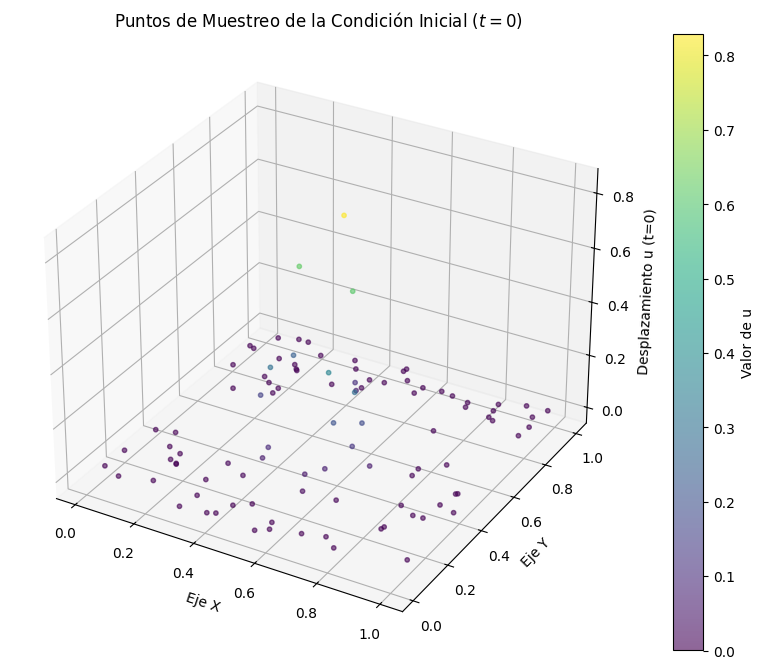

In [4]:
def plot_initial_condition_points(ic_batch):
    x_i, y_i, t_i, u_target, u_target_t = ic_batch
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Graficamos los puntos de muestreo
    # c=u_target usa el valor de u para el color (viva el colormap 'viridis' o 'jet')
    img = ax.scatter(x_i, y_i, u_target, c=u_target, cmap='viridis', alpha=0.6, s=10)
    
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Desplazamiento u (t=0)')
    ax.set_title('Puntos de Muestreo de la Condición Inicial ($t=0$)')
    
    fig.colorbar(img, ax=ax, label='Valor de u')
    plt.show()

# Llamada a la función con tu batch actual
plot_initial_condition_points(ic_batch)

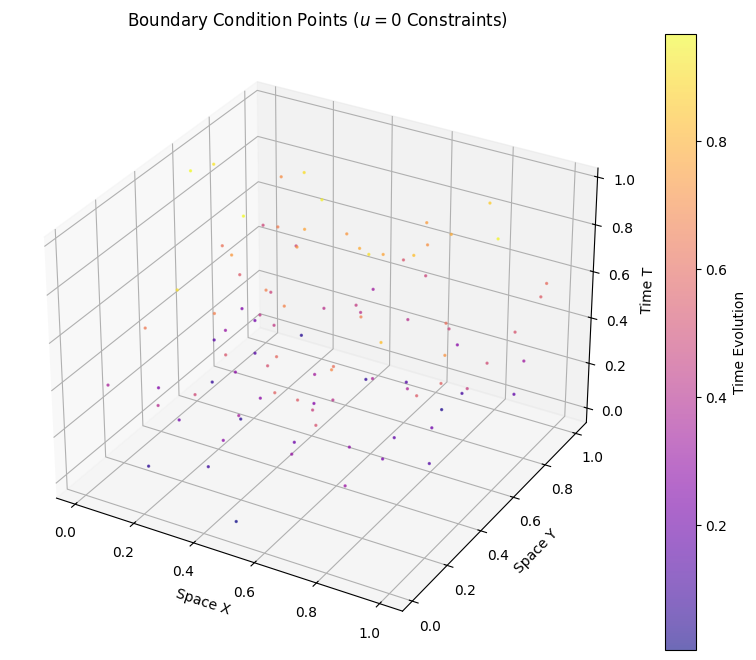

In [5]:
def plot_boundary_points(bc_batch):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract coordinates from the (N, 3) matrix
    x_b, y_b, t_b = bc_batch
    
    # We color by time to see the progression
    scatter = ax.scatter(x_b, y_b, t_b, c=t_b, cmap='plasma', s=2, alpha=0.6)
    
    ax.set_xlabel('Space X')
    ax.set_ylabel('Space Y')
    ax.set_zlabel('Time T')
    ax.set_title('Boundary Condition Points ($u=0$ Constraints)')
    
    plt.colorbar(scatter, label='Time Evolution')
    plt.show()

# Visualize your current boundary batch
plot_boundary_points(bc_batch)

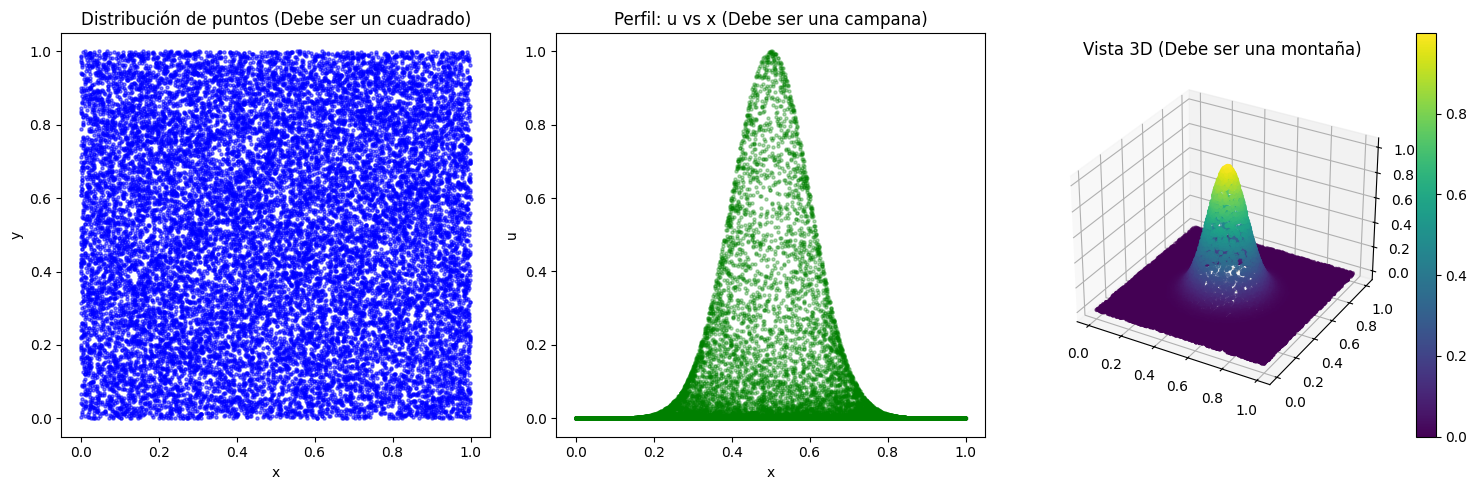

In [3]:


def debug_initial_condition(ic_batch):
    x_i, y_i, t_i, u_target, u_target_t = ic_batch
    
    fig = plt.figure(figsize=(15, 5))

    # Gráfico 1: Distribución en el plano XY (Vista aérea)
    ax1 = fig.add_subplot(131)
    ax1.scatter(x_i, y_i, s=5, alpha=0.5, c='blue')
    ax1.set_title("Distribución de puntos (Debe ser un cuadrado)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")

    # Gráfico 2: Perfil X vs U (Corte lateral)
    ax2 = fig.add_subplot(132)
    ax2.scatter(x_i, u_target, s=5, alpha=0.3, c='green')
    ax2.set_title("Perfil: u vs x (Debe ser una campana)")
    ax2.set_xlabel("x")
    ax2.set_ylabel("u")

    # Gráfico 3: 3D Scatter
    ax3 = fig.add_subplot(133, projection='3d')
    p = ax3.scatter(x_i, y_i, u_target, c=u_target, cmap='viridis', s=5)
    ax3.set_title("Vista 3D (Debe ser una montaña)")
    fig.colorbar(p, ax=ax3)
    
    plt.tight_layout()
    plt.show()

debug_initial_condition(ic_batch)

In [6]:


# 5. Optimization Loop
#params = init_params([3, 64, 64, 1], key)
params = init_params(layers, key)

# --- 1. The Adam Part (Global Search) ---
lr_schedule = optax.exponential_decay(1e-3, 1000, 0.9)
adam_opt = optax.adam(lr_schedule)
opt_state = adam_opt.init(params)



In [ ]:


@jit
def train_step_adam(carry, _, pde_batch, ic_batch, bc_batch):
    params, opt_state = carry
    grads = jax.grad(loss_fn)(params, pde_batch, ic_batch, bc_batch)
    updates, opt_state = adam_opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return (params, opt_state), None

# Ejecutar 5000 pasos de Adam de un tirón
print("Fase 1: Optimizando con Adam...")
train_step_partial = functools.partial(train_step_adam, pde_batch=pde_batch, ic_batch=ic_batch, bc_batch=bc_batch)
(params, opt_state), _ = jax.lax.scan(train_step_partial, (params, opt_state), jnp.arange(5000))


In [7]:

@jit
def step(params, opt_state, pde_batch, ic_batch, bc_batch):
    grads = grad(loss_fn)(params, pde_batch, ic_batch, bc_batch)
    #updates, opt_state = optimizer.update(grads, opt_state)
    updates, opt_state = adam_opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state

# Initialize lists to store history
loss_history = []
steps_list = []



In [8]:


print("Starting training...")
for i in range(STEPS):
    params, opt_state = step(params, opt_state, pde_batch, ic_batch, bc_batch)
    # Record loss every 10 steps to keep it smooth but detailed
    #pde_x, pde_y, pde_t = pde_batch
    #ic_x, ic_y, ic_t, ic_u, ic_u_t = ic_batch
    if i % 10 == 0:
        curr_loss = loss_fn(params, pde_batch, ic_batch, bc_batch)
        loss_history.append(float(curr_loss))
        steps_list.append(i)
        
    if i % 500 == 0:
        print(f"Step {i}, Loss: {curr_loss:.6f}")
        create_batchs(key, n_points_bulk, n_points_boundary, n_points_initial_time, xi, xf, yi, yf, ti, tf)
    


Starting training...
Step 0, Loss: 0.476202
Step 500, Loss: 0.181751
Step 1000, Loss: 0.177489
Step 1500, Loss: 0.168641
Step 2000, Loss: 0.146657
Step 2500, Loss: 0.137519
Step 3000, Loss: 0.130877
Step 3500, Loss: 0.125281
Step 4000, Loss: 0.121383
Step 4500, Loss: 0.118470
Step 5000, Loss: 0.115945
Step 5500, Loss: 0.113491
Step 6000, Loss: 0.113466
Step 6500, Loss: 0.108493
Step 7000, Loss: 0.105348
Step 7500, Loss: 0.102065
Step 8000, Loss: 0.099306
Step 8500, Loss: 0.097653
Step 9000, Loss: 0.096563
Step 9500, Loss: 0.095610
Step 10000, Loss: 0.094623
Step 10500, Loss: 0.093571
Step 11000, Loss: 0.092447
Step 11500, Loss: 0.091235
Step 12000, Loss: 0.089906
Step 12500, Loss: 0.088437
Step 13000, Loss: 0.086855
Step 13500, Loss: 0.085217
Step 14000, Loss: 0.083555
Step 14500, Loss: 0.081759
Step 15000, Loss: 0.079881
Step 15500, Loss: 0.078390
Step 16000, Loss: 0.077148
Step 16500, Loss: 0.076329
Step 17000, Loss: 0.075652
Step 17500, Loss: 0.075020
Step 18000, Loss: 0.074371
Step

In [14]:
# --- 2. The L-BFGS Part (Precision) ---
print("Fase 2: Refinando con L-BFGS...")

# JAXopt requiere una función que solo dependa de los parámetros
def objective(p):
    return loss_fn(p, pde_batch, ic_batch, bc_batch)

lbfgs = jaxopt.LBFGS(fun=objective, maxiter=500)
lbfgs_results = lbfgs.run(params)

params = lbfgs_results.params
print(f"Final Loss: {lbfgs_results.state.error}")

Fase 2: Refinando con L-BFGS...
Final Loss: 0.11952047049999237


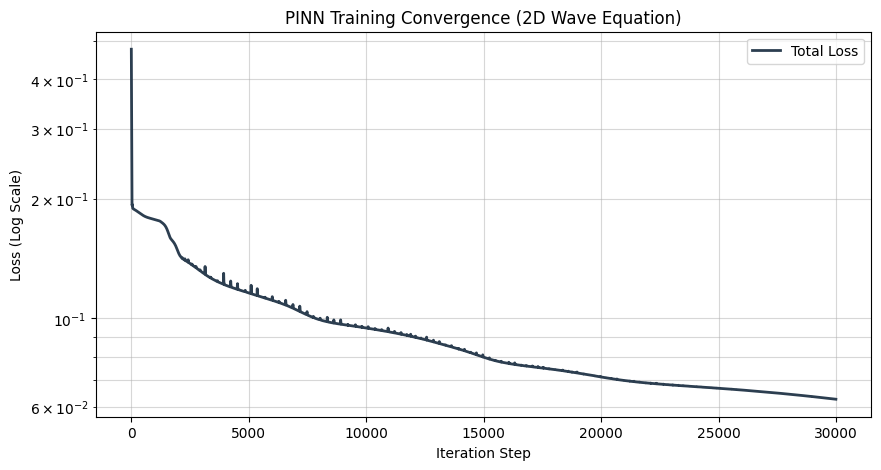

In [9]:
# 2. Plotting the Loss Function
plt.figure(figsize=(10, 5))
plt.plot(steps_list, loss_history, label='Total Loss', color='#2c3e50', linewidth=2)
plt.yscale('log') # PINN loss is best viewed on a log scale
plt.xlabel('Iteration Step')
plt.ylabel('Loss (Log Scale)')
plt.title('PINN Training Convergence (2D Wave Equation)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

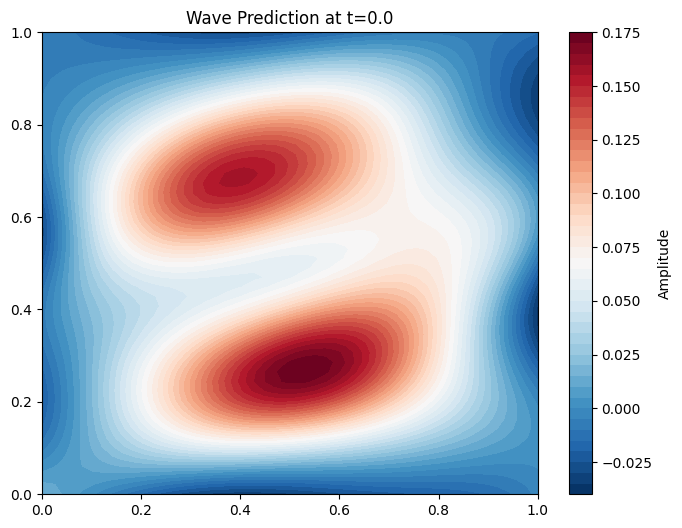

In [15]:

# 6. Visualization
x_range = jnp.linspace(0, 1, 50)
y_range = jnp.linspace(0, 1, 50)
X, Y = jnp.meshgrid(x_range, y_range)
u_final = vmap(forward, (None, 0, 0, 0))(params, X.flatten(), Y.flatten(), jnp.full(X.size, 0.2))

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, u_final.reshape(50, 50), levels=50, cmap='RdBu_r')
plt.colorbar(label='Amplitude')
plt.title("Wave Prediction at t=0.0")
plt.show()